# Mini Project: Conditional GAN trên FashionMNIST

Sau khi chạy xong notebook, bạn sẽ có:
- Loss của Generator và Discriminator

## Lưu ý
- Đã cố định seed để kết quả ổn định hơn.
- Tuy nhiên, do môi trường Colab có thể khác nhau, các giá trị loss có thể dao động nhẹ.

# 1. Import thư viện

In [3]:
import math
import random
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, Subset

from torchvision import datasets, transforms
from torchvision.utils import make_grid

seed = 42
random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)
torch.cuda.manual_seed_all(seed)

torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

Device: cuda


# 2. Tải FashionMNIST dataset và DataLoader

In [4]:
# ======================================
# Tải FashionMNIST và DataLoader
# ======================================
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

train_dataset = datasets.FashionMNIST(
    root="./data",
    train=True,
    download=True,
    transform=transform
)

# Chỉ lấy một phần dữ liệu để chạy nhanh
subset_size = 12000
indices = list(range(subset_size))
train_subset = Subset(train_dataset, indices)

batch_size = 128
train_loader = DataLoader(
    train_subset,
    batch_size=batch_size,
    shuffle=True,
    num_workers=0
)

class_names = train_dataset.classes
print("Số mẫu train subset:", len(train_subset))
print("Classes:", class_names)

100%|██████████| 26.4M/26.4M [00:00<00:00, 115MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 3.94MB/s]
100%|██████████| 4.42M/4.42M [00:00<00:00, 67.0MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 4.61MB/s]


Số mẫu train subset: 12000
Classes: ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat', 'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']


In [11]:
train_dataset.data[0].shape

torch.Size([28, 28])

# 3. Generator Block

In [38]:
# ===========================
# Generator
# ===========================
class Generator(nn.Module):
    def __init__(self, z_dim=100, num_classes=10, emb_dim=20):
        super().__init__()
        self.z_dim = z_dim
        self.num_classes = num_classes
        self.emb_dim = emb_dim

        self.label_emb = nn.Embedding(num_classes, emb_dim)
        self.fc = nn.Linear(z_dim + emb_dim, 128 * 7 * 7)

        self.decoder = nn.Sequential(
            nn.BatchNorm2d(128),
            nn.ConvTranspose2d(128, 64, kernel_size=4, stride=2, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(True),

            nn.ConvTranspose2d(64, 1, kernel_size=4, stride=2, padding=1),
            nn.Tanh()
        )

    def forward(self, z, y):
        # TODO 1: xử lý nhãn điều kiện bằng embedding
        y_emb = self.label_emb(y)

        # TODO 2: ghép z và y_emb theo chiều đặc trưng
        x = torch.cat([z, y_emb], 1)
        # print('second shape', x.shape)

        # TODO 3: đưa qua fully connected
        x = self.fc(x)

        # TODO 4: reshape về tensor 4 chiều
        x = x.view(x.size(0), 128, 7, 7)

        # TODO 5: đưa qua decoder / upsampling
        out = self.decoder(x)

        return out

# 4. Discriminator Block

In [39]:
# ================================
# Discriminator
# ================================
class Discriminator(nn.Module):
    def __init__(self, num_classes=10, emb_dim=28*28):
        super().__init__()
        self.num_classes = num_classes
        self.emb_dim = emb_dim

        self.label_emb = nn.Embedding(num_classes, emb_dim)

        self.model = nn.Sequential(
            nn.Conv2d(2, 64, kernel_size=4, stride=2, padding=1),
            nn.LeakyReLU(0.2, inplace=True),

            nn.Conv2d(64, 128, kernel_size=4, stride=2, padding=1),
            nn.BatchNorm2d(128),
            nn.LeakyReLU(0.2, inplace=True),

            nn.Flatten(),
            nn.Linear(128 * 7 * 7, 1),
            nn.Sigmoid()
        )

    def forward(self, img, y):
        batch_size = img.size(0)
        y_emb = self.label_emb(y)
        y_map = y_emb.view(batch_size, 1, 28, 28)
        x = torch.cat([img, y_map], dim=1)
        out = self.model(x)
        return out

# 5. Khởi tạo model và optimizer

In [40]:
# ===================================
# Khởi tạo model và optimizer
# ===================================
z_dim = 100
num_classes = 10
lr = 2e-4

G = Generator(z_dim=z_dim, num_classes=num_classes, emb_dim=20).to(device)
D = Discriminator(num_classes=num_classes, emb_dim=28*28).to(device)

criterion = nn.BCELoss()
optimizer_G = torch.optim.Adam(G.parameters(), lr=lr, betas=(0.5, 0.999))
optimizer_D = torch.optim.Adam(D.parameters(), lr=lr, betas=(0.5, 0.999))

print("Generator parameters:", sum(p.numel() for p in G.parameters()))
print("Discriminator parameters:", sum(p.numel() for p in D.parameters()))

Generator parameters: 891657
Discriminator parameters: 147681


# 6. Training Phase

In [41]:
# ==========================================
# Hàm train đầy đủ
# ==========================================
def train_cgan(G, D, train_loader, optimizer_G, optimizer_D, criterion, z_dim, device, epochs=3):
    G.train()
    D.train()

    history = {
        "g_loss": [],
        "d_loss": []
    }

    for epoch in range(epochs):
        running_g = 0.0
        running_d = 0.0
        count = 0

        for real_imgs, labels in train_loader:
            real_imgs = real_imgs.to(device)
            labels = labels.to(device)
            batch_size = real_imgs.size(0)

            real_targets = torch.ones(batch_size, 1, device=device)
            fake_targets = torch.zeros(batch_size, 1, device=device)

            # Train D
            optimizer_D.zero_grad()

            z = torch.randn(batch_size, z_dim, device=device)
            fake_imgs = G(z, labels)

            pred_real = D(real_imgs, labels)
            pred_fake = D(fake_imgs.detach(), labels)

            loss_real = criterion(pred_real, real_targets)
            loss_fake = criterion(pred_fake, fake_targets)
            d_loss = 0.5 * (loss_real + loss_fake)

            d_loss.backward()
            optimizer_D.step()

            # Train G
            optimizer_G.zero_grad()

            z = torch.randn(batch_size, z_dim, device=device)
            fake_imgs = G(z, labels)
            pred_fake_for_g = D(fake_imgs, labels)

            g_loss = criterion(pred_fake_for_g, real_targets)

            g_loss.backward()
            optimizer_G.step()

            running_g += g_loss.item()
            running_d += d_loss.item()
            count += 1

        avg_g = running_g / count
        avg_d = running_d / count

        history["g_loss"].append(avg_g)
        history["d_loss"].append(avg_d)

        print(f"Epoch [{epoch+1}/{epochs}] - G_loss: {avg_g:.4f} - D_loss: {avg_d:.4f}")

    return history

In [42]:
# ===================================
# Train nhanh trên Colab
# ===================================
epochs = 3
history = train_cgan(
    G, D, train_loader,
    optimizer_G, optimizer_D,
    criterion,
    z_dim=z_dim,
    device=device,
    epochs=epochs
)

final_g = history["g_loss"][-1]
final_d = history["d_loss"][-1]
print("\nKết quả cuối cùng:")
print("Final G_loss =", round(final_g, 4))
print("Final D_loss =", round(final_d, 4))

Epoch [1/3] - G_loss: 2.1438 - D_loss: 0.2098
Epoch [2/3] - G_loss: 1.5782 - D_loss: 0.3528
Epoch [3/3] - G_loss: 1.4041 - D_loss: 0.3784

Kết quả cuối cùng:
Final G_loss = 1.4041
Final D_loss = 0.3784


# 7. Vẽ đồ thị loss

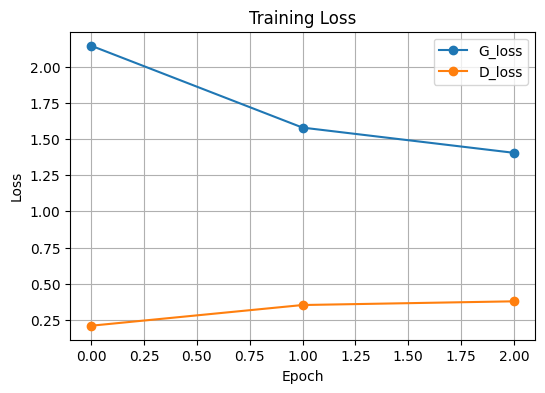

In [43]:
# =========================================
# Vẽ đồ thị loss
# =========================================
plt.figure(figsize=(6,4))
plt.plot(history["g_loss"], marker="o", label="G_loss")
plt.plot(history["d_loss"], marker="o", label="D_loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Loss")
plt.legend()
plt.grid(True)
plt.show()